In [1]:
import numpy as np
import pandas as pd
train = pd.read_csv("../data/raw/train_FD002.txt", sep=r"\s+", header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [2]:
train.describe()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,...,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000,53759.000000
mean,131.082981,109.154746,23.998407,0.572056,94.046020,472.910207,579.672399,1419.971013,1205.442024,8.031986,...,266.069034,2334.557253,8066.597682,9.329654,0.023326,348.309511,2228.806358,97.756838,20.789296,12.473423
std,74.463862,69.180569,14.747376,0.310016,14.237735,26.389707,37.289399,105.946341,119.123428,3.613839,...,137.659507,128.068271,84.837950,0.749335,0.004711,27.754515,145.327980,5.364067,9.869331,5.921615
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,1243.730000,1023.770000,3.910000,...,129.120000,2027.610000,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.180000,6.010500
25%,68.000000,52.000000,10.004600,0.250700,100.000000,445.000000,549.570000,1352.760000,1123.655000,3.910000,...,131.520000,2387.900000,8062.140000,8.677800,0.020000,331.000000,2212.000000,100.000000,10.910000,6.546300
50%,131.000000,104.000000,25.001300,0.700000,100.000000,462.540000,555.980000,1369.180000,1138.890000,7.050000,...,183.200000,2388.080000,8082.540000,9.310900,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929200
75%,195.000000,157.000000,41.998000,0.840000,100.000000,491.190000,607.340000,1499.370000,1306.850000,10.520000,...,371.260000,2388.170000,8127.195000,9.386900,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083200
max,260.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,1612.880000,1439.230000,14.620000,...,523.370000,2390.480000,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.340000,23.590100


In [3]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]
train.columns = columns
train.head(5)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


In [4]:
engine_1 = train[train["engine_id"]==1]
engine_1.shape

(149, 26)

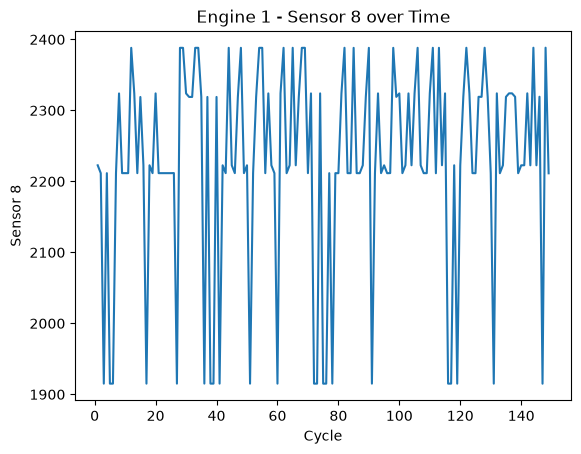

In [5]:
import matplotlib.pyplot as plt
plt.plot(engine_1["cycle"], engine_1["sensor_8"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 8")
plt.title("Engine 1 - Sensor 8 over Time")
plt.show()

In [6]:
train.nunique()

engine_id      260
cycle          378
setting_1      536
setting_2      105
setting_3        2
sensor_1         6
sensor_2      1590
sensor_3     12305
sensor_4     15411
sensor_5         6
sensor_6        14
sensor_7      2067
sensor_8       897
sensor_9     22434
sensor_10        9
sensor_11      681
sensor_12     1672
sensor_13      514
sensor_14    14905
sensor_15     8464
sensor_16        2
sensor_17       53
sensor_18        6
sensor_19        2
sensor_20      510
sensor_21    17837
dtype: int64

so there are total of 260 engines and no sensor or setting has 0 unique values

In [7]:
train.columns

Index(['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='str')

In [8]:
usefull_sensors = ['setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

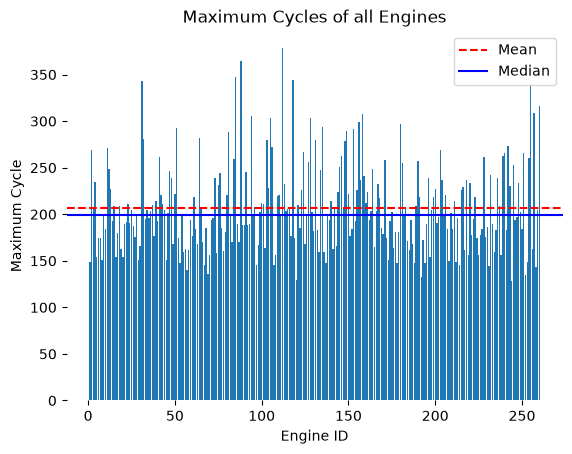

In [9]:
max_cycles = train.groupby("engine_id")["cycle"].max()
plt.bar(max_cycles.index, max_cycles.values)
plt.xlabel("Engine ID")
plt.ylabel("Maximum Cycle")
plt.title("Maximum Cycles of all Engines")
plt.axhline(y=max_cycles.mean(), color="r", linestyle="--", label="Mean")
plt.axhline(y=max_cycles.median(), color="b", linestyle="-", label="Median")
legend = plt.legend()
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

In [10]:
#lets add rul
train["rul"] = train["engine_id"].map(max_cycles) - train["cycle"]

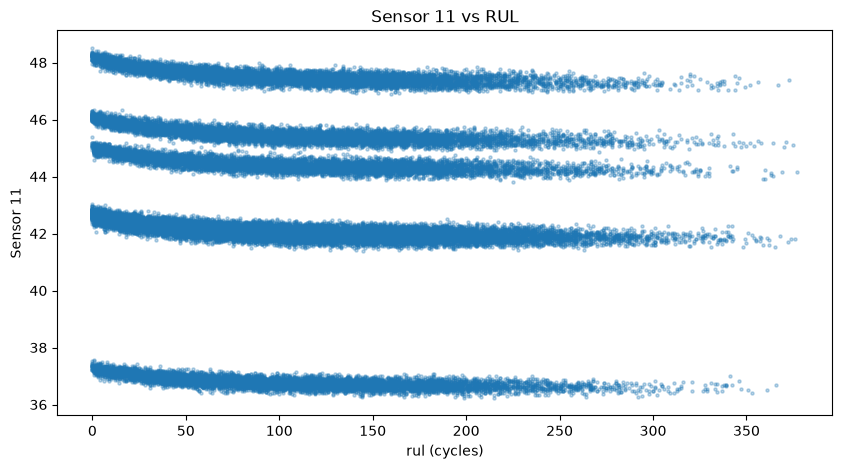

In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(
    train["rul"],
    train["sensor_11"],
    s=5,
    alpha=0.3
)
plt.xlabel("rul (cycles)")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 vs RUL")
plt.show()

In [12]:
engine_corrs = []
for engine_id , group in train.groupby("engine_id"):
    correlations = group[usefull_sensors].corrwith(group["cycle"])
    correlations["engine_id"] = engine_id
    engine_corrs.append(correlations)

engine_corrs = pd.DataFrame(engine_corrs).set_index("engine_id")
engine_corrs.head(10)

,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
engine_id,,,,,,,,,,,,,,,,,,,,,
1.0,-0.076703,-0.035098,0.102044,0.080934,0.111665,0.141088,0.134751,0.079478,0.086485,0.090833,...,0.091113,0.102335,0.083859,-0.074319,0.182340,0.136413,0.121807,0.102044,0.088515,0.088017
2.0,0.063580,0.062376,-0.026641,-0.088166,-0.080052,-0.048731,-0.038815,-0.078990,-0.080151,-0.082591,...,-0.082270,-0.026046,0.012473,0.079033,0.030890,-0.051269,-0.059638,-0.026641,-0.085507,-0.084563
3.0,-0.052811,-0.024139,0.016198,0.077938,0.083755,0.096129,0.106529,0.077506,0.077917,0.071826,...,0.072234,0.016458,0.004224,0.022769,0.104265,0.096682,0.047335,0.016198,0.065673,0.066574
4.0,-0.054620,-0.048547,-0.098581,0.022810,-0.002914,0.006184,0.025461,0.042722,0.034647,0.021279,...,0.021360,-0.097070,0.128519,0.090438,0.067900,0.011036,-0.070689,-0.098581,0.022692,0.021161
5.0,0.025215,0.031790,0.062808,-0.005259,0.026326,0.062425,0.060262,-0.010681,-0.004154,0.000464,...,0.001117,0.064080,0.175160,-0.004676,-0.005745,0.064125,0.051472,0.062808,-0.006071,-0.007015
6.0,0.177923,0.124806,0.088454,-0.151457,-0.099585,-0.050627,-0.041358,-0.149436,-0.139213,-0.125730,...,-0.125330,0.088089,0.013524,0.029397,-0.024378,-0.050872,0.002945,0.088454,-0.138478,-0.139089
7.0,-0.190515,-0.171472,-0.010591,0.168056,0.150510,0.155924,0.181197,0.181401,0.177809,0.168262,...,0.168296,-0.009125,0.228341,-0.038301,0.191921,0.160948,0.061077,-0.010591,0.167158,0.169568
8.0,-0.057714,-0.030937,0.020718,0.080585,0.084425,0.099421,0.103004,0.070349,0.070760,0.065977,...,0.066084,0.020837,0.005255,0.003005,0.039791,0.099530,0.051239,0.020718,0.062861,0.061403
9.0,0.021402,0.063527,-0.003763,-0.022998,-0.014735,0.005858,0.001930,-0.030981,-0.031692,-0.036294,...,-0.036119,-0.003759,-0.061957,0.059976,0.053363,0.002170,-0.012324,-0.003763,-0.036859,-0.037171


In [13]:
from sklearn.model_selection import train_test_split
engine_ids = train["engine_id"].unique()
train_engines, val_engines = train_test_split(engine_ids, test_size=0.2, random_state=42)
print("Training Engines:",len(train_engines))
print("Validation Engines:",len(val_engines))

Training Engines: 208
Validation Engines: 52


In [14]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
print("traing rows: ",len(train_data))
print("validation rows: ",len(val_data))

traing rows:  43464
validation rows:  10295


In [15]:
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["rul"]

X_val = val_data[feature_col]
Y_val = val_data["rul"]

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  31.022883924235064
baseline RMSE:  41.421318162271774


<Axes: >

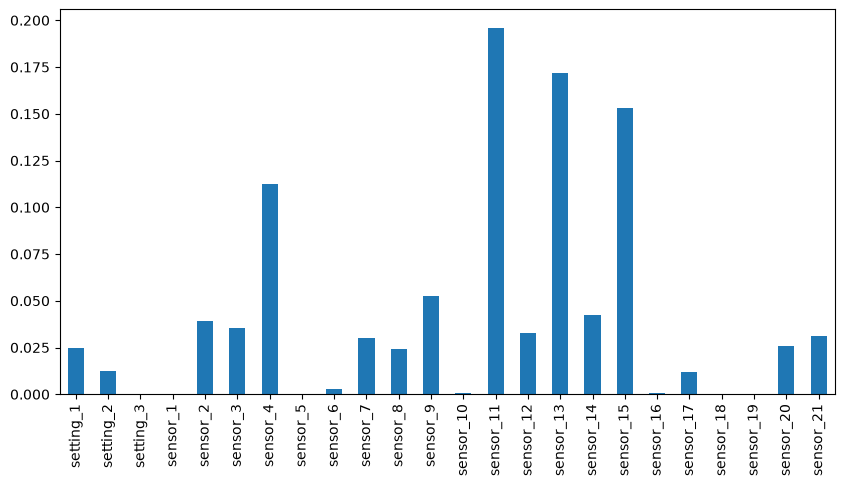

In [17]:
feature_importance = pd.Series(baseline_model.feature_importances_, index=feature_col)#.sort_values(ascending=False)
feature_importance.plot(kind="bar", figsize=(10, 5))

looks like setting 3 sensor 1,5,18,19 dosent have anything much to do with our prediction lets try our model after removing them
but lets confrim this using permutation importance

In [18]:
from sklearn.inspection import permutation_importance
prem_importance = permutation_importance(baseline_model, X_val, Y_val, n_repeats=15, random_state=42, n_jobs=-1, scoring="neg_mean_absolute_error")
prem_importance_df = pd.DataFrame({
    "sensor": feature_col,
    "importance": prem_importance.importances_mean,
    "importance_std": prem_importance.importances_std
})
prem_importance_df

,sensor,importance,importance_std
0,setting_1,0.902629,0.028283
1,setting_2,0.417937,0.028653
2,setting_3,-0.000001,0.000003
3,sensor_1,0.003248,0.000709
4,sensor_2,2.126581,0.060001
5,sensor_3,1.331442,0.059575
6,sensor_4,5.890361,0.141432
7,sensor_5,0.000119,0.000269
8,sensor_6,0.085014,0.011556
9,sensor_7,1.234764,0.045817


looks like sensor 1 and 18 might be woth keeping 

In [19]:

remove = ["setting_3","sensor_5","sensor_19"]
usefull_sensors = [
    x for x in usefull_sensors
    if x not in remove
]

In [20]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
print("traing rows: ",len(train_data))
print("validation rows: ",len(val_data))

traing rows:  43464
validation rows:  10295


In [21]:
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["rul"]

X_val = val_data[feature_col]
Y_val = val_data["rul"]

In [22]:
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  30.99255949490044
baseline RMSE:  41.39575380828326


In [23]:
window = 5
for col in usefull_sensors:
    train[f"{col}_rmean"]=(train.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).mean()))
    train[f"{col}_rstd"]=(train.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0)))

In [24]:
train.columns

Index(['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'rul',
       'setting_1_rmean', 'setting_1_rstd', 'setting_2_rmean',
       'setting_2_rstd', 'sensor_1_rmean', 'sensor_1_rstd', 'sensor_2_rmean',
       'sensor_2_rstd', 'sensor_3_rmean', 'sensor_3_rstd', 'sensor_4_rmean',
       'sensor_4_rstd', 'sensor_6_rmean', 'sensor_6_rstd', 'sensor_7_rmean',
       'sensor_7_rstd', 'sensor_8_rmean', 'sensor_8_rstd', 'sensor_9_rmean',
       'sensor_9_rstd', 'sensor_10_rmean', 'sensor_10_rstd', 'sensor_11_rmean',
       'sensor_11_rstd', 'sensor_12_rmean', 'sensor_12_rstd',
       'sensor_13_rmean', 'sensor_13_rstd', 'sensor_14_rmean',
       'sensor_14_rstd', 'sensor_15_rmean', 'sensor_15_r

In [25]:
usefull_sensors = ['setting_1', 'setting_2', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_20', 'sensor_21',
       'setting_1_rmean', 'setting_1_rstd', 'setting_2_rmean',
       'setting_2_rstd', 'sensor_1_rmean', 'sensor_1_rstd', 'sensor_2_rmean',
       'sensor_2_rstd', 'sensor_3_rmean', 'sensor_3_rstd', 'sensor_4_rmean',
       'sensor_4_rstd', 'sensor_6_rmean', 'sensor_6_rstd', 'sensor_7_rmean',
       'sensor_7_rstd', 'sensor_8_rmean', 'sensor_8_rstd', 'sensor_9_rmean',
       'sensor_9_rstd', 'sensor_10_rmean', 'sensor_10_rstd', 'sensor_11_rmean',
       'sensor_11_rstd', 'sensor_12_rmean', 'sensor_12_rstd',
       'sensor_13_rmean', 'sensor_13_rstd', 'sensor_14_rmean',
       'sensor_14_rstd', 'sensor_15_rmean', 'sensor_15_rstd',
       'sensor_16_rmean', 'sensor_16_rstd', 'sensor_17_rmean',
       'sensor_17_rstd', 'sensor_18_rmean', 'sensor_18_rstd',
       'sensor_20_rmean', 'sensor_20_rstd', 'sensor_21_rmean',
       'sensor_21_rstd']

In [26]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
print("traing rows: ",len(train_data))
print("validation rows: ",len(val_data))

traing rows:  43464
validation rows:  10295


In [27]:
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["rul"]

X_val = val_data[feature_col]
Y_val = val_data["rul"]

In [28]:
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  30.878056338028166
baseline RMSE:  41.138879484443315


still error is too high lets try capping the rul value

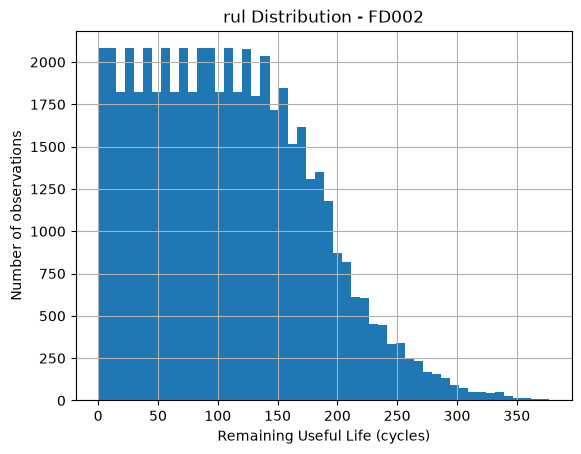

In [29]:
train["rul"].hist(bins=50)
plt.xlabel("Remaining Useful Life (cycles)")
plt.ylabel("Number of observations")
plt.title("rul Distribution - FD002")
plt.show()

In [30]:
(train["rul"] > 140).sum()

np.int64(17144)

In [31]:
train["RUL_capped"] = train["rul"].clip(upper=140)

train[["rul", "RUL_capped"]].head()

,rul,RUL_capped
0,148,140
1,147,140
2,146,140
3,145,140
4,144,140


In [32]:
train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()
feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["RUL_capped"]
X_val = val_data[feature_col]
Y_val = val_data["RUL_capped"]

In [33]:
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  18.074597377367652
baseline RMSE:  23.632519653177983


error is still to high lets try to identify 6 condition and then train the model

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

settings = train[
    ["setting_1", "setting_2", "setting_3"]
]

scaler = StandardScaler()
settings_scaled = scaler.fit_transform(settings)

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

train["condition"] = kmeans.fit_predict(settings_scaled)

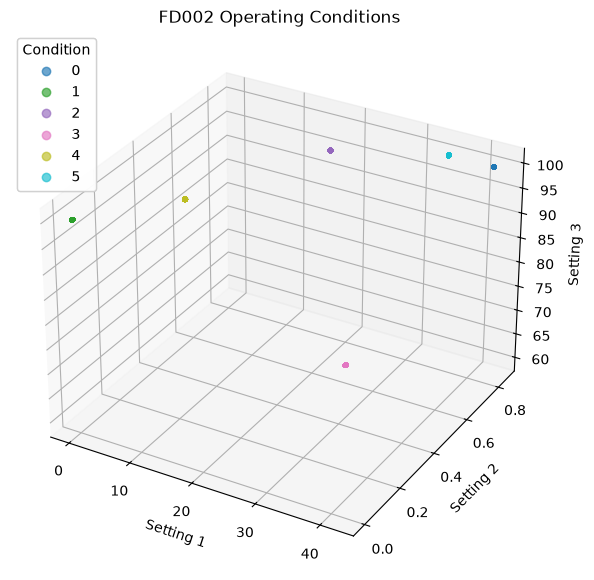

In [35]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    train["setting_1"],
    train["setting_2"],
    train["setting_3"],
    c=train["condition"],
    cmap="tab10",
    s=8,
    alpha=0.6
)

ax.set_xlabel("Setting 1")
ax.set_ylabel("Setting 2")
ax.set_zlabel("Setting 3")

ax.set_title("FD002 Operating Conditions")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Condition"
)

ax.add_artist(legend)

plt.show()

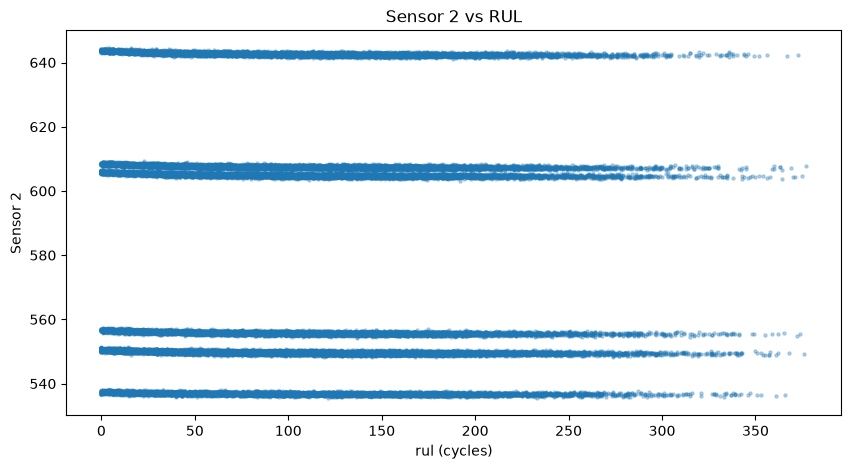

In [36]:
plt.figure(figsize=(10, 5))
plt.scatter(
    train["rul"],
    train["sensor_2"],
    s=5,
    alpha=0.3
)
plt.xlabel("rul (cycles)")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 vs RUL")
plt.show()

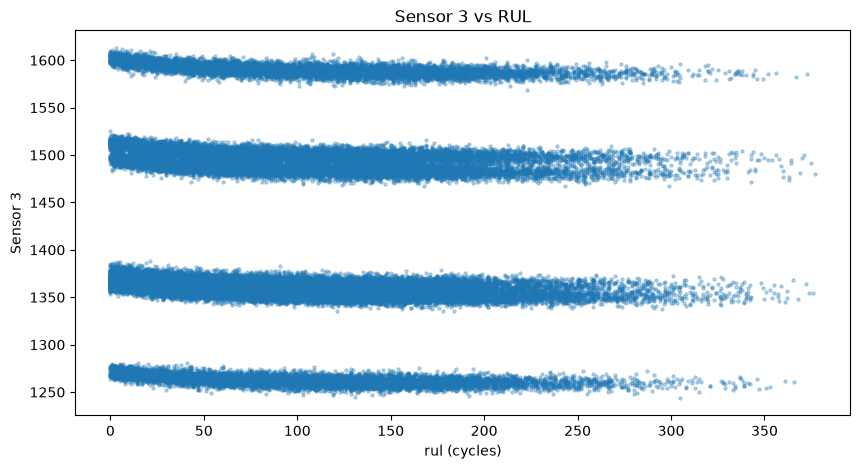

In [37]:
plt.figure(figsize=(10, 5))
plt.scatter(
    train["rul"],
    train["sensor_3"],
    s=5,
    alpha=0.3
)
plt.xlabel("rul (cycles)")
plt.ylabel("Sensor 3")
plt.title("Sensor 3 vs RUL")
plt.show()

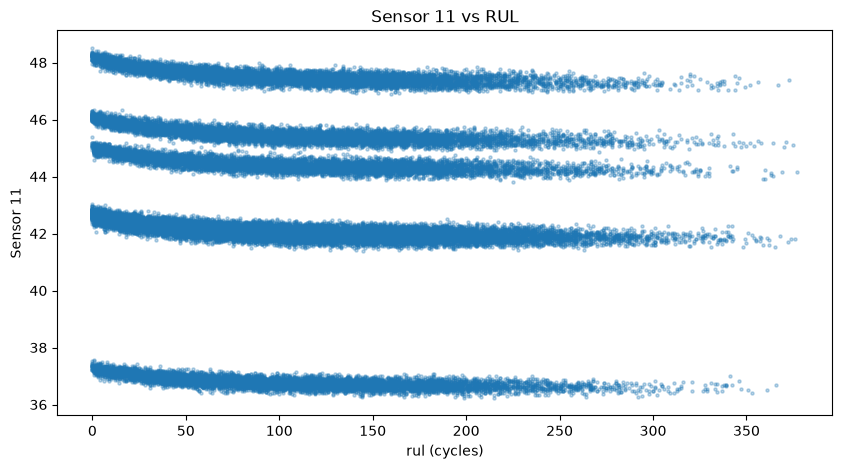

In [38]:
plt.figure(figsize=(10, 5))
plt.scatter(
    train["rul"],
    train["sensor_11"],
    s=5,
    alpha=0.3
)
plt.xlabel("rul (cycles)")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 vs RUL")
plt.show()

it is clear that sensor has different values as per the conditon they are in as we see in the graph

In [39]:
def normalize_by_condition(df, stats, cols):
    df = df.copy()
    for col in cols:
        df[col] = (df[col] - df["condition"].map(stats[(col, "mean")])) / df["condition"].map(stats[(col, "std")])
    return df

In [40]:
from sklearn.preprocessing import StandardScaler
condition_cols = ["setting_1", "setting_2", "setting_3"]
scaler = StandardScaler()
scaled_settings = scaler.fit_transform(train[condition_cols])
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train["condition"] = kmeans.fit_predict(scaled_settings)
print(train["condition"].value_counts())  # sanity check: ~6 balanced groups

sensor_cols = ['setting_1', 'setting_2', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
               'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
               'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
               'sensor_18', 'sensor_20', 'sensor_21']
condition_stats = train.groupby("condition")[sensor_cols].agg(["mean", "std"])
train = normalize_by_condition(train, condition_stats, sensor_cols)

window = 10
for col in sensor_cols:
    train[f"{col}_rmean"] = train.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).mean())
    train[f"{col}_rstd"] = train.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))


condition
0    13458
2     8122
4     8096
1     8044
5     8037
3     8002
Name: count, dtype: int64


In [41]:
usefull_sensors = sensor_cols + [f"{c}_rmean" for c in sensor_cols] + [f"{c}_rstd" for c in sensor_cols]

train_data = train[train["engine_id"].isin(train_engines)].copy()
val_data = train[train["engine_id"].isin(val_engines)].copy()

feature_col = usefull_sensors
X_train = train_data[feature_col]
Y_train = train_data["RUL_capped"]
X_val = val_data[feature_col]
Y_val = val_data["RUL_capped"]

baseline_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, Y_train)
y_pred = baseline_model.predict(X_val)
print("baseline MAE: ", mean_absolute_error(Y_val, y_pred))
print("baseline RMSE: ", np.sqrt(mean_squared_error(Y_val, y_pred)))

baseline MAE:  16.77450607090821
baseline RMSE:  22.494826310146344


lets try different models

In [42]:
from xgboost import XGBRegressor
import numpy as np

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train
model.fit(X_train, Y_train)

# Predict
predictions = model.predict(X_val)

# Calculate errors
mae = mean_absolute_error(Y_val, predictions)
rmse = np.sqrt(mean_squared_error(Y_val, predictions))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 16.514034271240234
RMSE: 22.430617443061017


In [43]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

# Train
model.fit(
    X_train, Y_train,
    eval_set=[(X_val, Y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30)]
)

# Predict
predictions = model.predict(X_val)

# Calculate errors
mae = mean_absolute_error(Y_val, predictions)
rmse = np.sqrt(mean_squared_error(Y_val, predictions))

print("MAE :", mae)
print("RMSE:", rmse)


Training until validation scores don't improve for 30 rounds


e:\software\predictive-maintenance\venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Early stopping, best iteration is:
[88]	valid_0's l1: 16.6052	valid_0's l2: 487.178
MAE : 16.605157781036482
RMSE: 22.072105474016652


lets test our test data set

In [44]:
test = pd.read_csv("../data/raw/test_FD002.txt", sep=r"\s+", header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,9.9987,0.2502,100.0,489.05,605.03,1497.17,1304.99,10.52,...,371.69,2388.18,8114.10,8.6476,0.03,369,2319,100.00,28.42,17.1551
1,1,2,20.0026,0.7000,100.0,491.19,607.82,1481.20,1246.11,9.35,...,315.32,2388.12,8053.06,9.2405,0.02,364,2324,100.00,24.29,14.8039
2,1,3,35.0045,0.8400,100.0,449.44,556.00,1359.08,1128.36,5.48,...,183.04,2387.75,8053.04,9.3472,0.02,333,2223,100.00,14.98,8.9125
3,1,4,42.0066,0.8410,100.0,445.00,550.17,1349.69,1127.89,3.91,...,130.40,2387.72,8066.90,9.3961,0.02,332,2212,100.00,10.35,6.4181
4,1,5,24.9985,0.6213,60.0,462.54,536.72,1253.18,1050.69,7.05,...,164.56,2028.05,7865.66,10.8682,0.02,305,1915,84.93,14.31,8.5740


In [45]:
columns = [
    "engine_id",
    "cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]
test.columns = columns

In [46]:
test["condition"] = kmeans.predict(scaler.transform(test[condition_cols]))

In [47]:
test = normalize_by_condition(test, condition_stats, sensor_cols)

In [48]:
window = 10
for col in sensor_cols:
    test[f"{col}_rmean"] = test.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).mean())
    test[f"{col}_rstd"] = test.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))

In [49]:
test_last = (
    test.sort_values(["engine_id", "cycle"])
        .groupby("engine_id")
        .tail(1)
        .sort_values("engine_id")
        .reset_index(drop=True)
)

In [50]:
X_test = test_last[usefull_sensors]
y_true = pd.read_csv("../data/raw/RUL_FD002.txt", header=None).squeeze()

y_pred = model.predict(X_test)  # your finalized LightGBM model

print("test MAE: ", mean_absolute_error(y_true, y_pred))
print("test RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))

test MAE:  19.20356654874708
test RMSE:  27.19244382946491
